In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
full = pd.read_csv("inventaire_oasis1.csv")  # ajuste le chemin si le CSV est ailleurs
print(f"{len(full)} sujets chargés depuis inventaire_oasis1.csv")
 
example = full[full["has_T88"] & full["has_FSL_SEG"]].iloc[0]
print("Sujet exemple :", example["subject_id"])

416 sujets chargés depuis inventaire_oasis1.csv
Sujet exemple : OAS1_0001_MR1


In [10]:
def load_volume(subject_path):
    """Charge le volume T88 normalisé (.img/.hdr ou .nii selon la release)."""
    t88_dir = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")
    candidates = glob.glob(os.path.join(t88_dir, "*.img")) + \
                 glob.glob(os.path.join(t88_dir, "*.nii*"))
    if not candidates:
        raise FileNotFoundError(f"Aucun volume trouvé dans {t88_dir}")
    img = nib.load(candidates[0])
    data = np.squeeze(img.get_fdata())
    return data, img.affine
 
 
volume, affine = load_volume(example["path"])

In [11]:
def load_fsl_seg(subject_path):
    """Charge le volume de segmentation tissulaire fourni par OASIS (FSL_SEG)."""
    seg_dir = os.path.join(subject_path, "FSL_SEG")
    candidates = glob.glob(os.path.join(seg_dir, "*.img")) + \
                 glob.glob(os.path.join(seg_dir, "*.nii*"))
    if not candidates:
        raise FileNotFoundError(f"Aucune segmentation trouvée dans {seg_dir}")
    img = nib.load(candidates[0])
    data = np.squeeze(img.get_fdata())
    return data, img.header.get_zooms()[:3]  # dimensions du voxel en mm

In [12]:
def compute_tissue_volumes(seg_data, voxel_dims):
    """
    Convertit les labels de segmentation en volumes (mL).
    Convention FSL_SEG typique : 0=fond, 1=LCR, 2=matière grise, 3=matière blanche
    (à vérifier avec np.unique sur tes données, ça peut varier légèrement).
    """
    voxel_volume_mm3 = np.prod(voxel_dims)  # ex: 1*1*1 = 1 mm^3 si espace T88_111
    labels, counts = np.unique(seg_data.astype(int), return_counts=True)
    volumes = {}
    label_names = {0: "background", 1: "CSF", 2: "gray_matter", 3: "white_matter"}
    for label, count in zip(labels, counts):
        name = label_names.get(label, f"label_{label}")
        volumes[name] = count * voxel_volume_mm3 / 1000.0  # mm^3 -> mL
    return volumes
 

In [13]:
def show_segmentation(volume, seg, title="Segmentation vs volume brut"):
    x, y, z = [s // 2 for s in volume.shape]
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(volume[:, :, z].T, cmap="gray", origin="lower")
    axes[0].set_title("T1 brut")
    axes[1].imshow(seg[:, :, z].T, cmap="viridis", origin="lower")
    axes[1].set_title("Segmentation FSL_SEG")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Dimensions du voxel (mm) : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Valeurs de labels présentes : [0 1 2 3]

Volumes calculés (mL) :
  background: 4775.7 mL
  CSF: 423.6 mL
  gray_matter: 742.5 mL
  white_matter: 501.2 mL


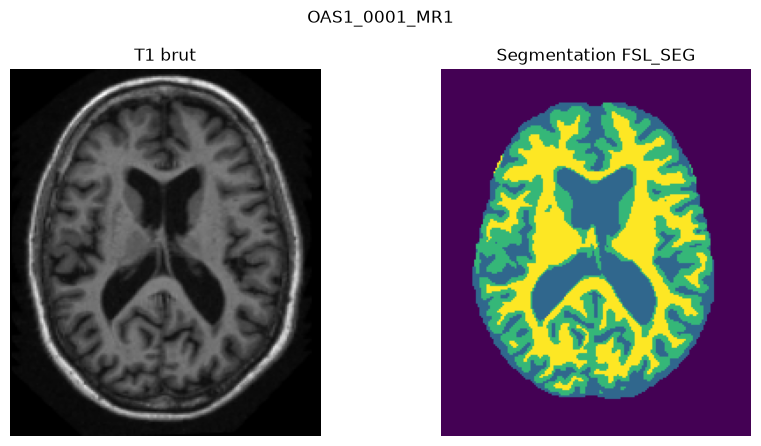

In [14]:
seg_data, voxel_dims = load_fsl_seg(example["path"])
print("Dimensions du voxel (mm) :", voxel_dims)
print("Valeurs de labels présentes :", np.unique(seg_data.astype(int)))
 
volumes = compute_tissue_volumes(seg_data, voxel_dims)
print("\nVolumes calculés (mL) :")
for name, vol in volumes.items():
    print(f"  {name}: {vol:.1f} mL")
 
show_segmentation(volume, seg_data, title=f"{example['subject_id']}")

In [15]:
def build_biomarker_table(full_df):
    """Parcourt tous les sujets ayant T88 + FSL_SEG et calcule leurs volumes."""
    rows = []
    subset = full_df[full_df["has_T88"] & full_df["has_FSL_SEG"]]
    for _, row in subset.iterrows():
        try:
            seg_data, voxel_dims = load_fsl_seg(row["path"])
            volumes = compute_tissue_volumes(seg_data, voxel_dims)
            total_brain = volumes.get("gray_matter", 0) + volumes.get("white_matter", 0)
            rows.append({
                "subject_id": row["subject_id"],
                "CDR": row.get("CDR"),
                "gray_matter_mL": volumes.get("gray_matter", np.nan),
                "white_matter_mL": volumes.get("white_matter", np.nan),
                "csf_mL": volumes.get("CSF", np.nan),
                "total_brain_mL": total_brain,
            })
        except Exception as e:
            print(f"Erreur pour {row['subject_id']} : {e}")
    return pd.DataFrame(rows)
 
 
biomarkers = build_biomarker_table(full)
print(f"\n{len(biomarkers)} sujets traités avec succès.")
biomarkers.to_csv("biomarkers_tissue_volumes.csv", index=False)
print("Sauvegardé : biomarkers_tissue_volumes.csv")
biomarkers.head()


416 sujets traités avec succès.
Sauvegardé : biomarkers_tissue_volumes.csv


,subject_id,CDR,gray_matter_mL,white_matter_mL,csf_mL,total_brain_mL
0,OAS1_0001_MR1,0.0,742.507,501.154,423.603,1243.661
1,OAS1_0002_MR1,0.0,811.579,543.332,312.353,1354.911
2,OAS1_0003_MR1,0.5,720.266,464.935,482.063,1185.201
3,OAS1_0004_MR1,NaN,818.074,527.251,321.939,1345.325
4,OAS1_0005_MR1,NaN,887.727,528.858,250.679,1416.585
